# Exploratory Data Analysis — CFPB Consumer Complaints

This notebook explores the raw consumer complaint dataset before any processing — missing values, date ranges, category distributions, and basic cross-tabs that informed the preprocessing and feature engineering pipeline.

**Note:** This EDA was run on a 500,000-row sample of the raw CSV for speed. The production pipeline (`preprocessing.py` onward) processes the full dataset (15M+ rows), so exact counts here will differ from the dashboard.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load Data

In [2]:
df = pd.read_csv(
    "../data/raw/complaints.csv",
    nrows=500000,
    low_memory=False
)

In [3]:
df.shape

(500000, 16)

In [4]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Submitted via', 'Date sent to company',
       'Company response to consumer', 'Timely response?', 'Complaint ID'],
      dtype='str')

In [5]:
df.head(2)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2024-04-22T21:58:40.000Z,Checking or savings account,Other banking product or service,Managing an account,Funds not handled or disbursed as instructed,Someone went inside the bank XX/XX/XXXX and wi...,Company has responded to the consumer and the ...,BMO BANK NATIONAL ASSOCIATION,CA,952XX,NaN,Web,2024-04-22T22:07:37.000Z,Closed with explanation,Yes,8827331
1,2024-09-17T00:13:45.000Z,Mortgage,Conventional home mortgage,Trouble during payment process,Loan sold or transferred to another company,NaN,NaN,Mr. Cooper Group Inc.,NY,11206,NaN,Phone,2024-10-30T19:46:11.000Z,Closed with explanation,Yes,10152997


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   Date received                 500000 non-null  str  
 1   Product                       500000 non-null  str  
 2   Sub-product                   499999 non-null  str  
 3   Issue                         500000 non-null  str  
 4   Sub-issue                     494731 non-null  str  
 5   Consumer complaint narrative  10216 non-null   str  
 6   Company public response       267158 non-null  str  
 7   Company                       500000 non-null  str  
 8   State                         499483 non-null  str  
 9   ZIP code                      499790 non-null  str  
 10  Tags                          9922 non-null    str  
 11  Submitted via                 500000 non-null  str  
 12  Date sent to company          500000 non-null  str  
 13  Company response to consu

## 2. Missing Values & Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": round((missing / len(df)) * 100, 2)
})

missing_df.sort_values("Missing_Percentage", ascending=False)

,Missing_Count,Missing_Percentage
Tags,490078,98.02
Consumer complaint narrative,489784,97.96
Company public response,232842,46.57
Sub-issue,5269,1.05
State,517,0.10
ZIP code,210,0.04
Issue,0,0.00
Date received,0,0.00
Company,0,0.00
Product,0,0.00


In [9]:
df[df['Consumer complaint narrative'].isnull()].head(2)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
1,2024-09-17T00:13:45.000Z,Mortgage,Conventional home mortgage,Trouble during payment process,Loan sold or transferred to another company,NaN,NaN,Mr. Cooper Group Inc.,NY,11206,NaN,Phone,2024-10-30T19:46:11.000Z,Closed with explanation,Yes,10152997
3,2024-10-18T18:11:00.000Z,Debt collection,I do not know,Attempts to collect debt not owed,Debt is not yours,NaN,Company believes it acted appropriately as aut...,Atlanticus Services Corporation,TX,75253,NaN,Web,2024-10-18T18:13:37.000Z,Closed with explanation,Yes,10502577


## 3. Tags (Consumer Group)

In [10]:
df["Tags"].value_counts(dropna=False)

Tags
NaN                              490078
Servicemember                      6867
Older American                     2546
Older American, Servicemember       509
Name: count, dtype: int64

In [11]:
pd.crosstab(df["Tags"], df["Product"])

Product,Checking or savings account,Credit card,Credit card or prepaid card,Credit reporting or other personal consumer reports,Debt collection,Debt or credit management,"Money transfer, virtual currency, or money service",Mortgage,"Payday loan, title loan, personal loan, or advance loan",Prepaid card,Student loan,Vehicle loan or lease
Tags,,,,,,,,,,,,
Older American,402,506,2,855,208,12,146,234,60,52,22,47
"Older American, Servicemember",80,90,0,122,57,4,23,83,21,9,5,15
Servicemember,475,473,0,4222,762,22,163,336,113,26,79,196


## 4. Date Features

Convert `Date received` to datetime, then derive Year/Month/Quarter/Day features used throughout the rest of the analysis and the dashboard.

In [12]:
df["Date received"] = pd.to_datetime(
    df["Date received"],
    format="mixed",
    errors="coerce",
    utc=True
)

df["Date sent to company"] = pd.to_datetime(
    df["Date sent to company"],
    format="mixed",
    errors="coerce",
    utc=True
)

In [13]:
df["Date received"].min(), df["Date received"].max()

(Timestamp('2012-01-20 01:31:14+0000', tz='UTC'),
 Timestamp('2026-06-18 03:56:57+0000', tz='UTC'))

In [14]:
df["Date received"].isna().sum()

np.int64(0)

In [15]:
df["Year"] = df["Date received"].dt.year
df["Month"] = df["Date received"].dt.month
df["Quarter"] = df["Date received"].dt.quarter
df["Day"] = df["Date received"].dt.day
df["Day_Name"] = df["Date received"].dt.day_name()

## 5. Complaint Volume Over Time

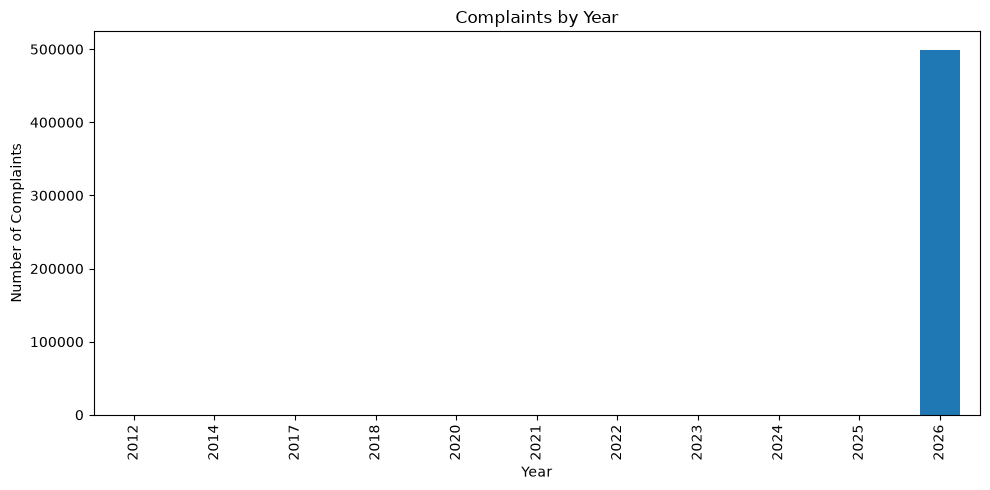

In [16]:
df["Year"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10, 5),
    title="Complaints by Year",
    xlabel="Year",
    ylabel="Number of Complaints",
)
plt.tight_layout()
plt.show()

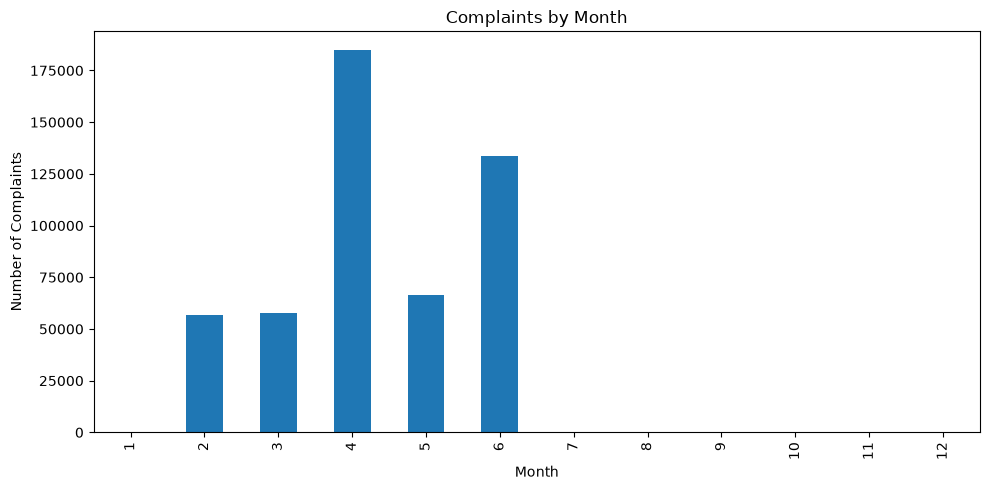

In [17]:
df["Month"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10, 5),
    title="Complaints by Month",
    xlabel="Month",
    ylabel="Number of Complaints",
)
plt.tight_layout()
plt.show()

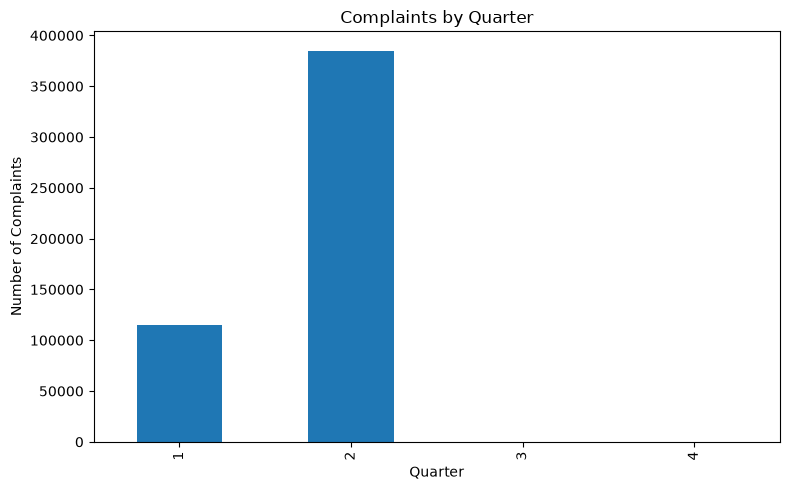

In [18]:
df["Quarter"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5),
    title="Complaints by Quarter",
    xlabel="Quarter",
    ylabel="Number of Complaints",
)
plt.tight_layout()
plt.show()

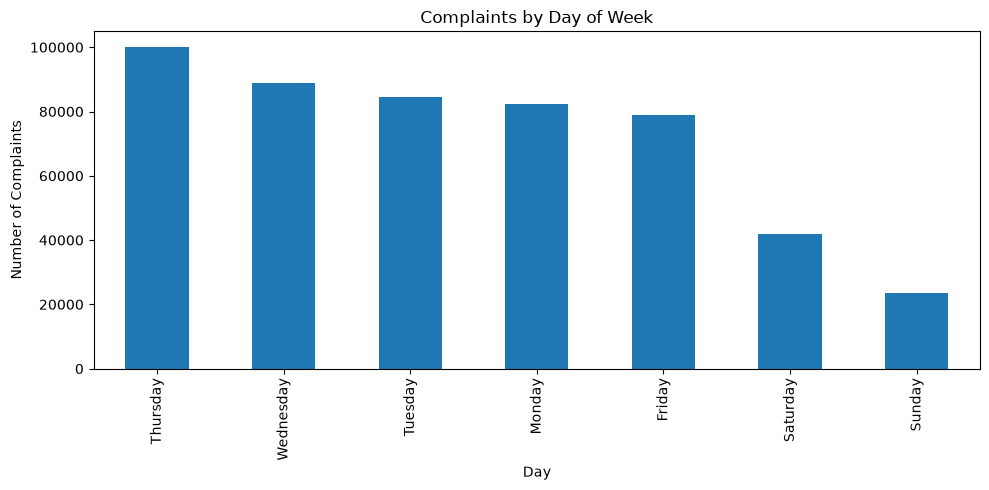

In [19]:
df["Day_Name"].value_counts().plot(
    kind="bar",
    figsize=(10, 5),
    title="Complaints by Day of Week",
    xlabel="Day",
    ylabel="Number of Complaints",
)
plt.tight_layout()
plt.show()

In [20]:
pd.crosstab(df["Year"], df["Product"])

Product,Checking or savings account,Credit card,Credit card or prepaid card,Credit reporting or other personal consumer reports,"Credit reporting, credit repair services, or other personal consumer reports",Debt collection,Debt or credit management,"Money transfer, virtual currency, or money service",Mortgage,"Payday loan, title loan, personal loan, or advance loan",Prepaid card,Student loan,Vehicle loan or lease
Year,,,,,,,,,,,,,
2012,0,1,0,0,0,0,0,0,1,0,0,0,0
2014,0,0,0,0,0,0,0,0,1,0,0,0,0
2017,0,0,0,0,1,1,0,0,1,0,0,0,0
2018,0,0,0,0,1,0,0,0,3,0,0,0,0
2020,1,0,3,0,2,3,0,0,1,0,0,0,0
2021,0,0,2,0,1,2,0,0,8,0,0,0,0
2022,1,0,2,0,0,1,0,1,3,0,0,0,0
2023,0,0,0,2,18,2,0,0,0,0,0,0,1
2024,3,2,0,29,0,3,1,2,4,0,0,0,0


In [21]:
pd.crosstab(df["Year"], df["Company response to consumer"])

Company response to consumer,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,Closed without relief,In progress,Untimely response
Year,,,,,,
2012,1,0,0,1,0,0
2014,1,0,0,0,0,0
2017,3,0,0,0,0,0
2018,3,0,1,0,0,0
2020,9,1,0,0,0,0
2021,12,0,1,0,0,0
2022,7,0,1,0,0,0
2023,18,0,5,0,0,0
2024,26,0,18,0,0,0


## 6. Product Analysis

In [22]:
df["Product"].nunique()

13

In [23]:
df["Product"].value_counts().head(10)

Product
Credit reporting or other personal consumer reports        456440
Debt collection                                             22113
Credit card                                                  6311
Checking or savings account                                  6006
Money transfer, virtual currency, or money service           2360
Mortgage                                                     2259
Vehicle loan or lease                                        1534
Student loan                                                 1187
Payday loan, title loan, personal loan, or advance loan      1066
Prepaid card                                                  423
Name: count, dtype: int64

In [24]:
pd.crosstab(df["Product"], df["Company response to consumer"])

Company response to consumer,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,Closed without relief,In progress,Untimely response
Product,,,,,,
Checking or savings account,4297,694,300,0,690,25
Credit card,4147,891,572,1,683,17
Credit card or prepaid card,7,0,0,0,0,0
Credit reporting or other personal consumer reports,284898,54,92285,0,79004,199
"Credit reporting, credit repair services, or other personal consumer reports",17,0,6,0,0,0
Debt collection,15759,26,4498,0,1372,458
Debt or credit management,179,15,25,0,40,12
"Money transfer, virtual currency, or money service",1828,221,127,0,145,39
Mortgage,1885,32,55,0,257,30


In [25]:
pd.crosstab(df["Product"], df["Timely response?"])

Timely response?,No,Yes
Product,,
Checking or savings account,53,5953
Credit card,62,6249
Credit card or prepaid card,1,6
Credit reporting or other personal consumer reports,385,456055
"Credit reporting, credit repair services, or other personal consumer reports",1,22
Debt collection,805,21308
Debt or credit management,25,246
"Money transfer, virtual currency, or money service",64,2296
Mortgage,46,2213


In [26]:
product_pct = (
    df["Product"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

product_pct

Product
Credit reporting or other personal consumer reports                             91.29
Debt collection                                                                  4.42
Credit card                                                                      1.26
Checking or savings account                                                      1.20
Money transfer, virtual currency, or money service                               0.47
Mortgage                                                                         0.45
Vehicle loan or lease                                                            0.31
Student loan                                                                     0.24
Payday loan, title loan, personal loan, or advance loan                          0.21
Prepaid card                                                                     0.08
Debt or credit management                                                        0.05
Credit reporting, credit repair services, or o

## 7. Sub-Product

In [27]:
df["Sub-product"].nunique()

55

In [28]:
df["Sub-product"].value_counts().head(20)

Sub-product
Credit reporting                              455105
I do not know                                  14338
General-purpose credit card or charge card      5519
Checking account                                4993
Other debt                                      2389
Credit card debt                                2349
Other personal consumer report                  1357
Loan                                            1291
Mobile or digital wallet                        1240
Conventional home mortgage                      1168
Federal student loan servicing                   950
Telecommunications debt                          888
Rental debt                                      870
Store credit card                                797
Installment loan                                 638
FHA mortgage                                     537
Medical debt                                     524
Domestic (US) money transfer                     520
Other banking product or service  

In [29]:
df["Sub-product"].isna().sum()

np.int64(1)

## 8. Timely Response

In [30]:
df["Timely response?"].value_counts()

Timely response?
Yes    498077
No       1923
Name: count, dtype: int64

In [31]:
(
    df["Timely response?"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Timely response?
Yes    99.62
No      0.38
Name: proportion, dtype: float64

In [32]:
pd.crosstab(df["Year"], df["Timely response?"])

Timely response?,No,Yes
Year,,
2012,0,2
2014,0,1
2017,0,3
2018,0,4
2020,0,10
2021,1,12
2022,1,7
2023,1,22
2024,3,41


## 9. Submission Channel

In [33]:
df["Submitted via"].value_counts()

Submitted via
Web            497649
Phone            1107
Referral          843
Postal mail       401
Name: count, dtype: int64

In [34]:
(
    df["Submitted via"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Submitted via
Web            99.53
Phone           0.22
Referral        0.17
Postal mail     0.08
Name: proportion, dtype: float64

## 10. Company Analysis

In [35]:
df["Company"].nunique()

1644

In [36]:
df["Company"].value_counts().head(20)

Company
TRANSUNION INTERMEDIATE HOLDINGS, INC.    166824
Experian Information Solutions Inc.       146510
EQUIFAX, INC.                             129143
LEXISNEXIS                                  3101
CAPITAL ONE FINANCIAL CORPORATION           2446
BANK OF AMERICA, NATIONAL ASSOCIATION       2066
Portfolio Recovery Associates, LLC          1823
CL Holdings LLC                             1815
JPMORGAN CHASE & CO.                        1765
CITIBANK, N.A.                              1662
WELLS FARGO & COMPANY                       1646
Resurgent Capital Services L.P.             1547
ENCORE CAPITAL GROUP INC.                   1486
SYNCHRONY FINANCIAL                         1289
AMERICAN EXPRESS COMPANY                     944
Block, Inc.                                  908
Chime Financial Inc                          839
CBC Companies, Inc.                          837
Bread Financial Holdings, Inc.               785
NAVY FEDERAL CREDIT UNION                    770
Name: count,

## 11. Geographic Analysis

**Note:** These are raw complaint counts by state, not normalized by state population — larger states will naturally show higher counts. Per-capita normalization is a planned improvement, not yet implemented here or in the dashboard.

In [37]:
df["State"].nunique()

61

In [38]:
df["State"].value_counts().head(20)

State
TX    82228
FL    71164
CA    45696
GA    37200
NY    25331
IL    21189
NC    17389
PA    16734
AL    14219
NJ    14164
SC    13322
LA    12672
MS    12470
MD    11241
OH     9626
MI     9525
VA     8248
AZ     7472
TN     6810
MA     6130
Name: count, dtype: int64

In [39]:
state_product = pd.crosstab(df["State"], df["Product"])

top_product_by_state = state_product.idxmax(axis=1)
top_count_by_state = state_product.max(axis=1)

state_summary = pd.DataFrame({
    "Top_Product": top_product_by_state,
    "Complaint_Count": top_count_by_state
}).sort_values("Complaint_Count", ascending=False)

state_summary.head(20)

,Top_Product,Complaint_Count
State,,
TX,Credit reporting or other personal consumer re...,76446
FL,Credit reporting or other personal consumer re...,66520
CA,Credit reporting or other personal consumer re...,40800
GA,Credit reporting or other personal consumer re...,34385
NY,Credit reporting or other personal consumer re...,23030
IL,Credit reporting or other personal consumer re...,19657
NC,Credit reporting or other personal consumer re...,15779
PA,Credit reporting or other personal consumer re...,15236
AL,Credit reporting or other personal consumer re...,13382


## 12. Issue Analysis

In [40]:
df["Issue"].nunique()

90

In [41]:
df["Issue"].value_counts(normalize=True).mul(100).round(2)

Issue
Incorrect information on your report                                                54.19
Improper use of your report                                                         19.22
Problem with a company's investigation into an existing problem                     17.42
Attempts to collect debt not owed                                                    2.07
Took or threatened to take negative or legal action                                  1.10
                                                                                    ...  
Application, originator, mortgage broker                                             0.00
Problem with a credit reporting company's investigation into an existing problem     0.00
Disclosure verification of debt                                                      0.00
Other fee                                                                            0.00
Loan servicing, payments, escrow account                                             0.00
Name

In [42]:
issue_product = pd.crosstab(df["Issue"], df["Product"])

pd.DataFrame({
    "Top_Product": issue_product.idxmax(axis=1),
    "Count": issue_product.max(axis=1)
}).sort_values("Count", ascending=False)

,Top_Product,Count
Issue,,
Incorrect information on your report,Credit reporting or other personal consumer re...,270042
Improper use of your report,Credit reporting or other personal consumer re...,96009
Problem with a company's investigation into an existing problem,Credit reporting or other personal consumer re...,86622
Attempts to collect debt not owed,Debt collection,10330
Took or threatened to take negative or legal action,Debt collection,5486
...,...,...
"Application, originator, mortgage broker",Mortgage,1
Problem with a credit reporting company's investigation into an existing problem,"Credit reporting, credit repair services, or o...",1
Other fee,Credit card,1


In [43]:
issue_company = pd.crosstab(df["Issue"], df["Company"])

pd.DataFrame({
    "Top_Company": issue_company.idxmax(axis=1),
    "Count": issue_company.max(axis=1)
}).sort_values("Count", ascending=False)

,Top_Company,Count
Issue,,
Incorrect information on your report,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",97763
Improper use of your report,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",36237
Problem with a company's investigation into an existing problem,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",31417
Attempts to collect debt not owed,CL Holdings LLC,818
Unable to get your credit report or credit score,"EQUIFAX, INC.",790
...,...,...
Incorrect exchange rate,JPMORGAN CHASE & CO.,1
Problems receiving the advance,"BANK OF AMERICA, NATIONAL ASSOCIATION",1
Problem with overdraft,"Block, Inc.",1


In [44]:
top_issues = df["Issue"].value_counts().head(10).index

pd.crosstab(
    df[df["Issue"].isin(top_issues)]["Issue"],
    df["Product"]
)

Product,Checking or savings account,Credit card,Credit reporting or other personal consumer reports,"Credit reporting, credit repair services, or other personal consumer reports",Debt collection,Mortgage,"Payday loan, title loan, personal loan, or advance loan",Student loan,Vehicle loan or lease
Issue,,,,,,,,,
Attempts to collect debt not owed,0,0,0,0,10330,0,0,0,0
False statements or representation,0,0,0,0,2111,0,0,0,0
Improper use of your report,4,48,96009,4,0,1,13,19,3
Incorrect information on your report,17,378,270042,17,0,78,52,205,148
Managing an account,3472,0,0,0,0,0,0,0,0
Problem with a company's investigation into an existing problem,10,275,86622,0,0,49,22,49,61
Problem with a purchase shown on your statement,0,2078,0,0,0,0,0,0,0
Problem with fraud alerts or security freezes,6,2,1576,0,0,0,2,3,0
Took or threatened to take negative or legal action,0,0,0,0,5486,0,0,0,0


In [45]:
df["Sub-issue"].nunique()

204

In [46]:
df["Sub-issue"].value_counts().head(20)

Sub-issue
Information belongs to someone else                                                      168809
Reporting company used your report improperly                                             81622
Account information incorrect                                                             59258
Investigation took more than 30 days                                                      43481
Their investigation did not fix an error on your report                                   39291
Account status incorrect                                                                  24258
Credit inquiries on your report that you don't recognize                                  14224
Personal information incorrect                                                            10323
Debt is not yours                                                                          6531
Threatened or suggested your credit would be damaged                                       5141
Information is missing that sh

## 13. Resolution & Company Response

In [47]:
df["Company response to consumer"].value_counts()

Company response to consumer
Closed with explanation            316368
Closed with non-monetary relief     98034
In progress                         82494
Closed with monetary relief          2050
Untimely response                    1053
Closed without relief                   1
Name: count, dtype: int64

In [48]:
df["Company public response"].value_counts()

Company public response
Company has responded to the consumer and the CFPB and chooses not to provide a public response                            264231
Company believes it acted appropriately as authorized by contract or law                                                     2404
Company disputes the facts presented in the complaint                                                                         160
Company can't verify or dispute the facts in the complaint                                                                    118
Company believes the complaint provided an opportunity to answer consumer's questions                                         118
Company believes complaint caused principally by actions of third party outside the control or direction of the company        50
Company believes the complaint is the result of a misunderstanding                                                             27
Company believes complaint represents an opportunity for improveme

In [49]:
df["Resolution_Delay"] = (
    df["Date sent to company"] - df["Date received"]
).dt.days

df["Resolution_Delay"].describe()

count    500000.000000
mean          0.319470
std           4.028536
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         356.000000
Name: Resolution_Delay, dtype: float64

In [50]:
df["Resolution_Delay"].value_counts().head(10)

Resolution_Delay
0     493608
1        453
6        304
2        283
42       257
8        213
35       197
7        190
9        186
3        164
Name: count, dtype: int64

## 14. Narrative Text

Quick look at narrative availability and length. Deeper text analysis (top words, n-grams, topic modeling, classifiers) lives in `02_nlp_analysis.ipynb`.

In [51]:
df["Consumer complaint narrative"].str.len().describe()

count    10216.000000
mean      1312.999706
std       1301.063057
min         49.000000
25%        478.000000
50%       1017.500000
75%       1719.250000
max      23743.000000
Name: Consumer complaint narrative, dtype: float64

## 15. Sanity Check Against Processed Pipeline Output

Quick cross-check: does the yearly complaint distribution from this raw 500K-row sample roughly match the full processed dataset, and does the growth analysis output look sane? This is a spot-check, not a full validation.

In [52]:
df1 = pd.read_parquet(
    "../data/processed/complaints_processed.parquet",
    columns=["Date received", "Year"]
)

df1["Year"].value_counts().sort_index()

Year
2011       2536
2012      72368
2013     108214
2014     152909
2015     168273
2016     191294
2017     242747
2018     257133
2019     277240
2020     444214
2021     495942
2022     800257
2023    1292053
2024    2734271
2025    5443009
2026    3269858
Name: count, dtype: int64

In [ ]:
issue_growth = pd.read_parquet(
    "../data/processed/dashboard/issue_growth.parquet"
)

issue_growth[
    [
        "Issue",
        "Previous_Year_Complaints",
        "Current_Year_Complaints",
        "YoY_Growth_Pct",
        "Growth_Label"
    ]
].head(20)

,Issue,Previous_Year_Complaints,Current_Year_Complaints,YoY_Growth_Pct,Growth_Label
0,Other transaction problem,3007.0,53893.0,1692.251413,Rising Fast
1,Took or threatened to take negative or legal a...,10751.0,48580.0,351.864943,Rising Fast
2,Other service problem,545.0,2064.0,278.715596,Rising Fast
3,Confusing or missing disclosures,784.0,2894.0,269.132653,Rising Fast
4,Unauthorized transactions or other transaction...,1660.0,5758.0,246.867470,Rising Fast
5,Problem caused by your funds being low,3530.0,11938.0,238.186969,Rising Fast
6,Incorrect information on your report,1191386.0,2834688.0,137.931955,Rising Fast
7,"Managing, opening, or closing your mobile wall...",758.0,1773.0,133.905013,Rising Fast
8,False statements or representation,16917.0,38462.0,127.357096,Rising Fast
9,Trouble accessing funds in your mobile or digi...,1366.0,3038.0,122.401171,Rising Fast


: 